# 04 — Detailed training-only EDA

Only `train.parquet` is loaded. Validation and test remain unopened. The analysis is organized around data quality, purchase-time availability, target relationships, and concrete feature decisions. Figures are both saved and rendered inline.

In [1]:
from pathlib import Path
import os, json
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert ROOT.name == "02-olist-late-delivery-ml"
SEED = 42
pd.set_option("display.max_columns", 100)
import matplotlib.pyplot as plt
import holidays

train_path = ROOT / "artifacts/03_splits/train.parquet"
df = pd.read_parquet(train_path)
assert train_path.name == "train.parquet"
figdir = ROOT / "artifacts/04_eda/figures"
figdir.mkdir(parents=True, exist_ok=True)

identifiers = ["order_id", "customer_id", "customer_unique_id"]
future_only = [
    "order_status", "order_approved_at", "order_delivered_carrier_date",
    "order_delivered_customer_date", "delivery_delta_hours",
]
datetime_columns = df.select_dtypes(include=["datetime"]).columns.tolist()
numeric_columns = df.select_dtypes(include="number").columns.tolist()
categorical_columns = df.select_dtypes(include=["object", "string"]).columns.tolist()
role_table = pd.DataFrame({
    "role": ["identifiers", "future/outcome-only", "numeric", "categorical", "datetime"],
    "columns": [identifiers, future_only, numeric_columns, categorical_columns, datetime_columns],
})
structure = {
    "rows": len(df), "columns": df.shape[1],
    "memory_mb": df.memory_usage(deep=True).sum() / 1e6,
}
display(structure, df.dtypes.rename("dtype").to_frame(), role_table)

{'rows': 67533, 'columns': 34, 'memory_mb': np.float64(58.577184)}

,dtype
order_id,object
customer_id,object
order_status,object
order_purchase_timestamp,datetime64[ns]
order_approved_at,datetime64[ns]
order_delivered_carrier_date,datetime64[ns]
order_delivered_customer_date,datetime64[ns]
order_estimated_delivery_date,datetime64[ns]
customer_unique_id,object
customer_zip_code_prefix,object


,role,columns
0,identifiers,"[order_id, customer_id, customer_unique_id]"
1,future/outcome-only,"[order_status, order_approved_at, order_delive..."
2,numeric,"[geo_lat, geo_lng, item_count, unique_product_..."
3,categorical,"[order_id, customer_id, order_status, customer..."
4,datetime,"[order_purchase_timestamp, order_approved_at, ..."


## Missingness and whether it relates to `late`

Missing product/geography fields may encode catalog or coverage differences. For each relevant candidate, the table compares target rates when missing versus observed. Outcome-column missingness is not a candidate feature because the information is unavailable at purchase.

In [2]:
missing = pd.DataFrame({
    "count": df.isna().sum(),
    "percentage": df.isna().mean() * 100,
}).query("count > 0").sort_values("percentage", ascending=False)

candidate_missing = [
    c for c in [
        "mean_product_weight_g", "mean_product_volume_cm3",
        "mean_product_photos_qty", "dominant_product_category",
        "geo_lat", "geo_lng", "mean_customer_seller_distance_km",
    ] if c in df
]
missing_target_rows = []
for column in candidate_missing:
    grouped = df.groupby(df[column].isna(), observed=True).late.agg(["size", "mean"])
    for is_missing, row in grouped.iterrows():
        missing_target_rows.append({
            "column": column, "is_missing": bool(is_missing),
            "orders": int(row["size"]), "late_rate": row["mean"],
        })
missing_target = pd.DataFrame(missing_target_rows)
display(missing, missing_target)

,count,percentage
dominant_product_category,1201,1.778390
mean_product_photos_qty,1197,1.772467
mean_customer_seller_distance_km,347,0.513823
max_customer_seller_distance_km,347,0.513823
geo_lat,181,0.268017
geo_lng,181,0.268017
mean_product_weight_g,16,0.023692
mean_product_volume_cm3,16,0.023692
order_approved_at,14,0.020731
order_delivered_carrier_date,1,0.001481


,column,is_missing,orders,late_rate
0,mean_product_weight_g,False,67517,0.078365
1,mean_product_weight_g,True,16,0.000000
2,mean_product_volume_cm3,False,67517,0.078365
3,mean_product_volume_cm3,True,16,0.000000
4,mean_product_photos_qty,False,66336,0.078374
5,mean_product_photos_qty,True,1197,0.076859
6,dominant_product_category,False,66332,0.078378
7,dominant_product_category,True,1201,0.076603
8,geo_lat,False,67352,0.078260
9,geo_lat,True,181,0.110497


## Numerical distributions, skew, outliers, and range checks

Percentiles, skew, and IQR outlier counts expose long tails without deleting valid large orders. Explicit domain checks look for negative monetary/dimension values and invalid counts. These checks separate suspicious values from merely skewed commerce data.

,count,mean,std,min,1%,25%,50%,75%,99%,max,skew,iqr_outlier_count
item_count,67533.0,1.142079,0.541635,1.00,1.00,1.00,1.00,1.000,3.0000,21.00,8.106935,6759
total_price,67533.0,135.884499,205.187627,2.29,11.99,45.90,85.00,149.900,987.0000,13440.00,10.719309,5361
total_freight,67533.0,22.244256,19.999582,0.00,7.78,14.10,16.79,23.700,98.1436,1002.29,8.584291,6629
payment_value,67532.0,158.167657,214.277783,10.07,22.95,61.63,104.19,175.485,1039.8504,13664.08,10.149896,5308
max_payment_installments,67532.0,2.974397,2.755007,1.00,1.00,1.00,2.00,4.000,10.0000,24.00,1.592864,4677
mean_product_weight_g,67517.0,2171.506409,3866.276477,2.00,100.00,300.00,700.00,1850.000,19100.0000,40425.00,3.579818,9768
mean_product_volume_cm3,67517.0,15842.177792,24160.935002,288.00,352.00,2880.00,6859.00,19500.000,115989.4400,294000.00,3.998428,5983
mean_product_photos_qty,66336.0,2.245242,1.743312,1.00,1.00,1.00,2.00,3.000,8.0000,20.00,1.938152,1936


{'negative_monetary_rows': 0,
 'nonpositive_item_count_rows': 0,
 'negative_dimension_or_weight_rows': 0,
 'installments_below_zero_rows': 0}

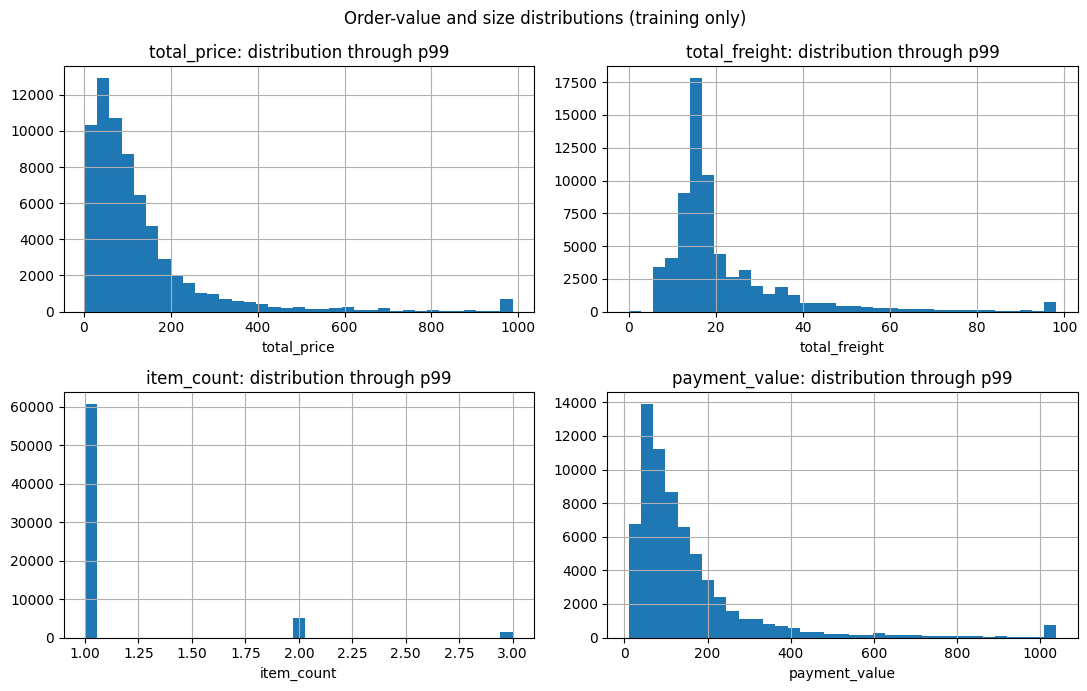

In [3]:
important_numeric = [
    "item_count", "total_price", "total_freight", "payment_value",
    "max_payment_installments", "mean_product_weight_g",
    "mean_product_volume_cm3", "mean_product_photos_qty",
]
numeric_summary = df[important_numeric].describe(
    percentiles=[.01, .25, .50, .75, .99]
).T
numeric_summary["skew"] = df[important_numeric].skew()
q1 = df[important_numeric].quantile(.25)
q3 = df[important_numeric].quantile(.75)
iqr = q3 - q1
numeric_summary["iqr_outlier_count"] = (
    (df[important_numeric] < q1 - 1.5 * iqr)
    | (df[important_numeric] > q3 + 1.5 * iqr)
).sum()

range_checks = {
    "negative_monetary_rows": int((df[["total_price", "total_freight", "payment_value"]] < 0).any(axis=1).sum()),
    "nonpositive_item_count_rows": int((df.item_count.dropna() <= 0).sum()),
    "negative_dimension_or_weight_rows": int((df[["mean_product_weight_g", "mean_product_volume_cm3"]] < 0).any(axis=1).sum()),
    "installments_below_zero_rows": int((df.max_payment_installments.dropna() < 0).sum()),
}
display(numeric_summary, range_checks)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for column, ax in zip(["total_price", "total_freight", "item_count", "payment_value"], axes.ravel()):
    df[column].clip(upper=df[column].quantile(.99)).hist(bins=35, ax=ax)
    ax.set_title(f"{column}: distribution through p99")
    ax.set_xlabel(column)
fig.suptitle("Order-value and size distributions (training only)")
fig.tight_layout()
fig.savefig(figdir / "numeric_distributions.png", dpi=140)
plt.show()

## Categorical quality, cardinality, and rarity

Whitespace/case-normalized uniqueness is compared with raw uniqueness to detect inconsistent labels. Rare groups are counted at fewer than 20 training observations; high-cardinality IDs and ZIP prefixes are not one-hot encoded.

In [4]:
categorical_quality = []
for column in categorical_columns:
    counts = df[column].value_counts(dropna=False)
    normalized = df[column].dropna().astype(str).str.strip().str.casefold()
    categorical_quality.append({
        "column": column,
        "cardinality_including_missing": int(df[column].nunique(dropna=False)),
        "normalized_cardinality": int(normalized.nunique()),
        "rare_categories_lt_20": int((counts < 20).sum()),
        "top_value": str(counts.index[0]),
        "top_count": int(counts.iloc[0]),
    })
categorical_quality = pd.DataFrame(categorical_quality)
display(categorical_quality)
display(df.dominant_product_category.value_counts(dropna=False).head(15))

,column,cardinality_including_missing,normalized_cardinality,rare_categories_lt_20,top_value,top_count
0,order_id,67533,67533,67533,bfbd0f9bdef84302105ad712db648a6c,1
1,customer_id,67533,67533,67533,86dc2ffce2dfff336de2f386a786e574,1
2,order_status,2,2,1,delivered,67527
3,customer_unique_id,65401,65401,65401,3e43e6105506432c953e165fb2acf44c,9
4,customer_zip_code_prefix,13748,13748,13338,22790,113
5,customer_city,3747,3747,3308,sao paulo,9921
6,customer_state,27,27,0,SP,27204
7,dominant_product_category,72,71,8,bed_bath_table,6630
8,dominant_seller_state,22,22,5,SP,47773
9,dominant_seller_zip_prefix,1679,1679,1130,14940,4767


dominant_product_category
bed_bath_table           6630
sports_leisure           5595
health_beauty            5379
computers_accessories    4781
furniture_decor          4537
housewares               3505
watches_gifts            3257
telephony                3066
toys                     2973
cool_stuff               2932
garden_tools             2637
auto                     2414
perfumery                2286
baby                     1862
electronics              1759
Name: count, dtype: int64

## Purchase-time derived candidates and target relationships

The promised window and freight/price ratio are evaluated here before feature engineering. Calendar features come strictly from purchase time. Cross-tabs inspect payment/state relationships, while correlations are limited to numeric associations and are not interpreted as causation.

In [5]:
eda = df.copy()
eda["purchase_month"] = eda.order_purchase_timestamp.dt.to_period("M").astype(str)
eda["purchase_weekday"] = eda.order_purchase_timestamp.dt.day_name()
eda["purchase_hour"] = eda.order_purchase_timestamp.dt.hour
eda["promised_window_days"] = (
    eda.order_estimated_delivery_date - eda.order_purchase_timestamp
).dt.total_seconds() / 86_400
eda["freight_price_ratio"] = eda.total_freight / eda.total_price.replace(0, np.nan)
eda["same_state_order"] = np.select(
    [eda.same_state_share.eq(1), eda.same_state_share.eq(0)], ["all_same", "none_same"],
    default="mixed_or_missing",
)

derived_summary = eda[["promised_window_days", "freight_price_ratio", "mean_customer_seller_distance_km"]].describe().T
target_groups = {
    "payment_type": eda.groupby("dominant_payment_type", dropna=False).late.agg(["size", "mean"]),
    "same_state": eda.groupby("same_state_order", dropna=False).late.agg(["size", "mean"]),
    "item_count_band": eda.groupby(pd.cut(eda.item_count, [-np.inf, 1, 2, 3, np.inf]), observed=True).late.agg(["size", "mean"]),
}
payment_crosstab = pd.crosstab(
    eda.dominant_payment_type, eda.late, normalize="index", margins=False
)
corr_columns = [
    "late", "total_price", "total_freight", "item_count", "payment_value",
    "max_payment_installments", "promised_window_days", "freight_price_ratio",
    "mean_customer_seller_distance_km", "same_state_share",
]
correlations = eda[corr_columns].corr(numeric_only=True)["late"].sort_values()
display(derived_summary, target_groups, payment_crosstab, correlations)

,count,mean,std,min,25%,50%,75%,max
promised_window_days,67533.0,24.597288,8.022133,7.005127,19.543333,23.621377,28.565984,155.135463
freight_price_ratio,67533.0,0.306290,0.292891,0.000000,0.132946,0.224118,0.377594,5.739496
mean_customer_seller_distance_km,67186.0,614.402471,593.986124,0.000000,219.181736,448.469814,810.641671,3387.319116


{'payment_type':                         size      mean
 dominant_payment_type                 
 boleto                 13901  0.081505
 credit_card            51561  0.077791
 debit_card               698  0.077364
 voucher                 1372  0.067055
 NaN                        1  1.000000,
 'same_state':                    size      mean
 same_state_order                 
 all_same          23005  0.044512
 mixed_or_missing    155  0.006452
 none_same         44373  0.096140,
 'item_count_band':               size      mean
 item_count                  
 (-inf, 1.0]  60774  0.080051
 (1.0, 2.0]    5201  0.063834
 (2.0, 3.0]     903  0.059801
 (3.0, inf]     655  0.061069}

late,0,1
dominant_payment_type,,
boleto,0.918495,0.081505
credit_card,0.922209,0.077791
debit_card,0.922636,0.077364
voucher,0.932945,0.067055


same_state_share                   -0.091204
promised_window_days               -0.018778
item_count                         -0.015031
max_payment_installments            0.017412
freight_price_ratio                 0.018775
total_price                         0.021834
payment_value                       0.025528
total_freight                       0.049654
mean_customer_seller_distance_km    0.087370
late                                1.000000
Name: late, dtype: float64

## Timeline, month, weekday, hour, and Brazilian holidays

Volume and late rate are plotted together to reveal temporal drift. Weekday/hour tables test whether purchase timing contributes signal. National holidays use the pinned `holidays` package and Brazil calendar, making the definition reproducible; only purchase-date holiday status is eligible.

,volume,late_rate
purchase_month,,
2016-09,1,1.000000
2016-10,270,0.007407
2016-12,1,0.000000
2017-01,750,0.029333
2017-02,1653,0.029643
2017-03,2546,0.045562
2017-04,2303,0.065567
2017-05,3545,0.029901
2017-06,3135,0.030303


,volume,late_rate
purchase_weekday,,
Monday,10736,0.085972
Tuesday,10729,0.079877
Wednesday,10339,0.075249
Thursday,10005,0.072464
Friday,9885,0.081740
Saturday,7594,0.078878
Sunday,8245,0.072893


,volume,late_rate
purchase_hour,,
0,1662,0.086643
1,837,0.082437
2,370,0.070270
3,186,0.048387
4,136,0.058824
5,134,0.059701
6,318,0.069182
7,806,0.073201
8,1951,0.074833


,volume,late_rate
purchase_is_holiday,,
0,66462,0.078752
1,1071,0.053221


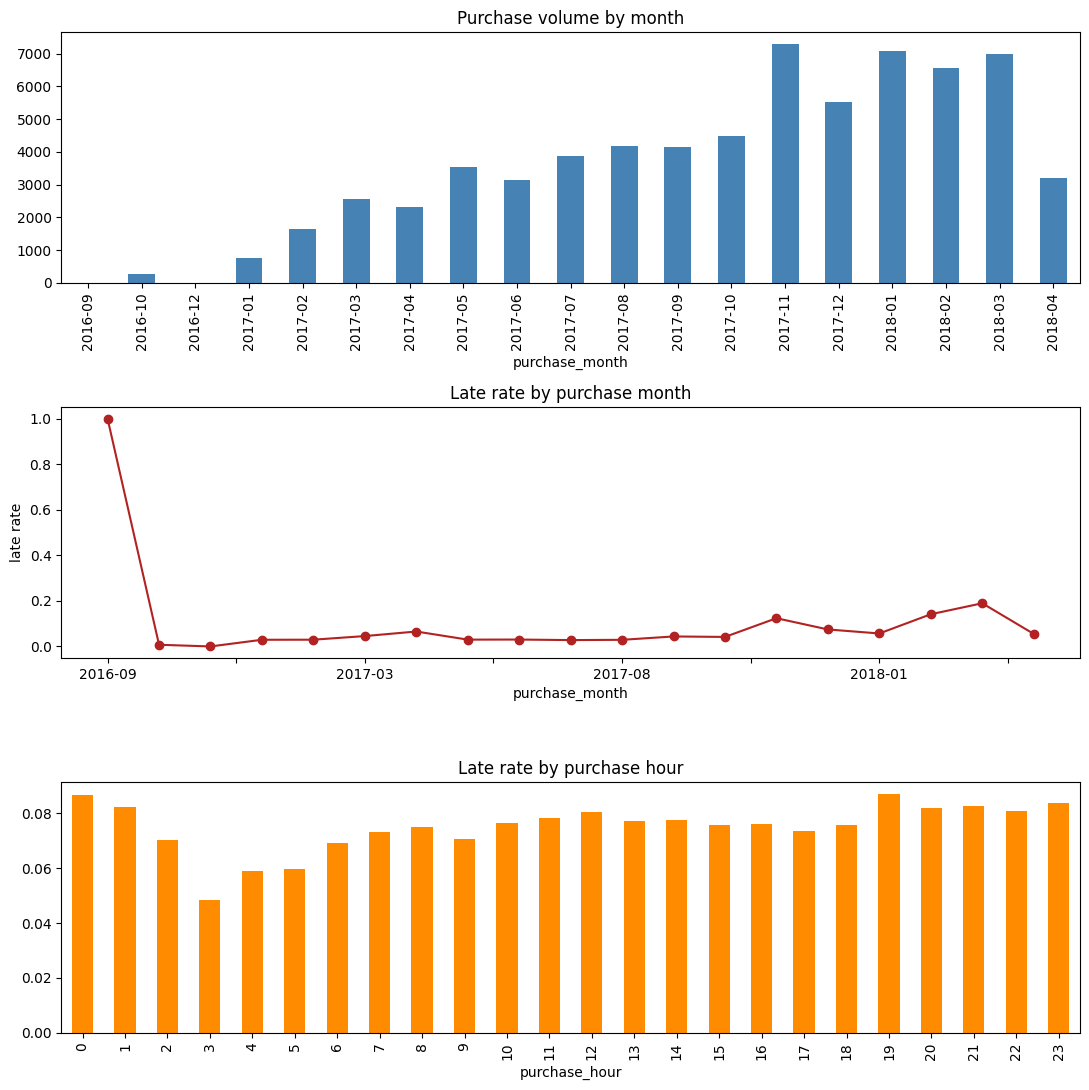

In [6]:
years = sorted(eda.order_purchase_timestamp.dt.year.unique())
brazil_holidays = holidays.Brazil(years=years)
eda["purchase_is_holiday"] = eda.order_purchase_timestamp.dt.date.map(
    lambda date: int(date in brazil_holidays)
)
monthly = eda.groupby("purchase_month").late.agg(volume="size", late_rate="mean")
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday = eda.groupby("purchase_weekday").late.agg(volume="size", late_rate="mean").reindex(weekday_order)
hourly = eda.groupby("purchase_hour").late.agg(volume="size", late_rate="mean")
holiday_effect = eda.groupby("purchase_is_holiday").late.agg(volume="size", late_rate="mean")
display(monthly, weekday, hourly, holiday_effect)

fig, axes = plt.subplots(3, 1, figsize=(11, 11))
monthly.volume.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Purchase volume by month")
monthly.late_rate.plot(kind="line", marker="o", ax=axes[1], color="firebrick")
axes[1].set_title("Late rate by purchase month")
axes[1].set_ylabel("late rate")
hourly.late_rate.plot(kind="bar", ax=axes[2], color="darkorange")
axes[2].set_title("Late rate by purchase hour")
fig.tight_layout()
fig.savefig(figdir / "time_patterns.png", dpi=140)
plt.show()

## Outcome-only delivery timing

Actual delivery duration and delay answer descriptive questions about historical outcomes but are explicitly forbidden features. Their distributions help validate label semantics and show how late orders differ in magnitude—not information available at purchase.

actual_delivery_days                                             \
                    count       mean        std       min        25%   
late                                                                   
0                 62242.0  11.920840   6.479793  0.533414   7.175943   
1                  5291.0  36.222088  17.396866  8.215961  26.540503   

                                       delay_days                        \
            50%        75%         max      count       mean        std   
late                                                                      
0     10.891030  15.378044   70.213611    62242.0 -12.720369   7.092221   
1     33.061331  41.324566  209.628611     5291.0  12.141472  15.571499   

                                                               
             min        25%        50%        75%         max  
late                                                           
0    -146.016123 -16.274277 -12.291574  -8.112665    0.996285  
1       1.003299   3.915856   7.807639  14.854809  188.975081

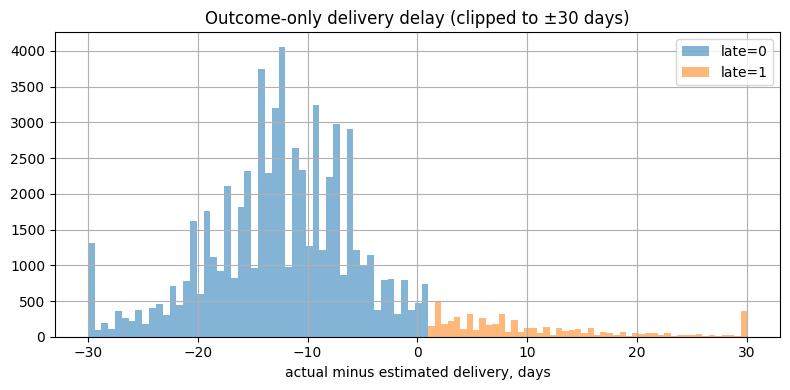

In [7]:
eda["actual_delivery_days"] = (
    eda.order_delivered_customer_date - eda.order_purchase_timestamp
).dt.total_seconds() / 86_400
eda["delay_days"] = (
    eda.order_delivered_customer_date - eda.order_estimated_delivery_date
).dt.total_seconds() / 86_400
delivery_summary = eda.groupby("late")[["actual_delivery_days", "delay_days"]].describe()
display(delivery_summary)

fig, ax = plt.subplots(figsize=(8, 4))
for label, group in eda.groupby("late"):
    group.delay_days.clip(-30, 30).hist(bins=50, alpha=.55, ax=ax, label=f"late={label}")
ax.set_title("Outcome-only delivery delay (clipped to ±30 days)")
ax.set_xlabel("actual minus estimated delivery, days")
ax.legend()
fig.tight_layout()
fig.savefig(figdir / "outcome_only_delay.png", dpi=140)
plt.show()

## Geography quality and relationships

Brazil bounds are checked explicitly. Out-of-bounds representative coordinates are retained upstream for auditability but were excluded from Haversine calculations. ZIP prefixes are described by cardinality only and excluded from the model to avoid brittle high-cardinality memorization. State, same-state relationship, and distances are evaluated at order grain.

{'customer_coordinate_rows_present': 67352,
 'customer_coordinate_rows_outside_brazil_bounds': 3,
 'customer_lat_range': [-33.690971840060584, 41.14620290949943],
 'customer_lng_range': [-72.67098698091266, -8.57785501800488],
 'customer_zip_prefix_cardinality': 13748,
 'customer_zip_prefix_singletons': 3577,
 'seller_zip_prefix_cardinality': 1679,
 'seller_zip_prefix_singletons': 272,
 'distance_missing_rows': 347,
 'distance_max_km': 3387.3191156535845}

,volume,late_rate
customer_state,,
RO,185,0.037838
AM,105,0.038095
AP,51,0.039216
AC,66,0.045455
SP,27204,0.046170
PR,3461,0.046229
MG,8130,0.052522
DF,1404,0.064815
RS,3912,0.074131


,volume,late_rate
dominant_seller_state,,
SP,47773,0.085299
MG,5664,0.055261
PR,5385,0.064438
RJ,2705,0.086876
SC,2588,0.054096
RS,1287,0.036519
DF,587,0.059625
BA,409,0.058680
GO,302,0.039735


,volume,late_rate
mean_customer_seller_distance_km,,
"(-0.001, 134.273]",13438,0.039664
"(134.273, 355.23]",13437,0.072338
"(355.23, 543.912]",13437,0.079110
"(543.912, 886.282]",13437,0.087966
"(886.282, 3387.319]",13437,0.112153


,volume,late_rate
same_state_order,,
all_same,23005,0.044512
mixed_or_missing,155,0.006452
none_same,44373,0.096140


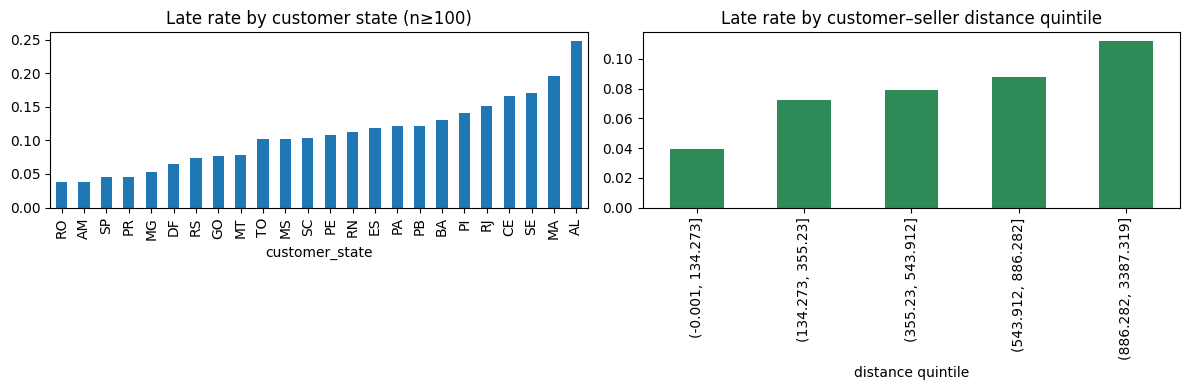

In [8]:
customer_valid = eda.geo_lat.between(-34, 6) & eda.geo_lng.between(-74, -34)
geography_quality = {
    "customer_coordinate_rows_present": int(eda[["geo_lat", "geo_lng"]].notna().all(axis=1).sum()),
    "customer_coordinate_rows_outside_brazil_bounds": int((~customer_valid & eda[["geo_lat", "geo_lng"]].notna().all(axis=1)).sum()),
    "customer_lat_range": [float(eda.geo_lat.min()), float(eda.geo_lat.max())],
    "customer_lng_range": [float(eda.geo_lng.min()), float(eda.geo_lng.max())],
    "customer_zip_prefix_cardinality": int(eda.customer_zip_code_prefix.nunique()),
    "customer_zip_prefix_singletons": int((eda.customer_zip_code_prefix.value_counts() == 1).sum()),
    "seller_zip_prefix_cardinality": int(eda.dominant_seller_zip_prefix.nunique()),
    "seller_zip_prefix_singletons": int((eda.dominant_seller_zip_prefix.value_counts() == 1).sum()),
    "distance_missing_rows": int(eda.mean_customer_seller_distance_km.isna().sum()),
    "distance_max_km": float(eda.max_customer_seller_distance_km.max()),
}
customer_state = eda.groupby("customer_state").late.agg(volume="size", late_rate="mean")
seller_state = eda.groupby("dominant_seller_state", dropna=False).late.agg(volume="size", late_rate="mean")
distance_bands = pd.qcut(eda.mean_customer_seller_distance_km, q=5, duplicates="drop")
distance_target = eda.groupby(distance_bands, observed=True).late.agg(volume="size", late_rate="mean")
same_state_target = eda.groupby("same_state_order").late.agg(volume="size", late_rate="mean")
display(geography_quality, customer_state.sort_values("late_rate"), seller_state.sort_values("volume", ascending=False), distance_target, same_state_target)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
customer_state.query("volume >= 100").late_rate.sort_values().plot(kind="bar", ax=axes[0])
axes[0].set_title("Late rate by customer state (n≥100)")
distance_target.late_rate.plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("Late rate by customer–seller distance quintile")
axes[1].set_xlabel("distance quintile")
fig.tight_layout()
fig.savefig(figdir / "geography_target_relationships.png", dpi=140)
plt.show()

## Leakage audit and evidence-driven decisions

The findings file below is the contract with Notebook 05. It distinguishes investigated variables from retained variables. Distance and same-state show interpretable logistics relationships and are retained; raw coordinates and ZIP prefix are not. Purchase holiday status is retained as a reproducible calendar feature even if its marginal rate difference is small. Outcome timing remains descriptive only.

In [9]:
negative_monetary_found = range_checks["negative_monetary_rows"] > 0
state_supported = customer_state.query("volume >= 100").late_rate
holiday_rate_difference = float(holiday_effect.late_rate.max() - holiday_effect.late_rate.min())
distance_rate_spread = float(distance_target.late_rate.max() - distance_target.late_rate.min())
same_state_rate_spread = float(same_state_target.late_rate.max() - same_state_target.late_rate.min())

retained = [
    "order/item/payment/product aggregates", "customer_state", "dominant_seller_state",
    "dominant_product_category", "dominant_payment_type", "purchase calendar",
    "promised_window_days", "freight_price_ratio", "purchase_is_holiday",
    "mean/max customer_seller_distance_km", "same_state_share",
]
excluded = [
    "raw latitude/longitude (quality risk and less interpretable than validated distance)",
    "ZIP prefix (high cardinality)", "identifiers", "future/outcome fields", "reviews",
]
findings = f"""# Training-only EDA findings

- Structure: {len(eda):,} training rows, {df.shape[1]} source columns, {structure['memory_mb']:.2f} MB; late rate {eda.late.mean():.2%}.
- Time: {eda.order_purchase_timestamp.min()} through {eda.order_purchase_timestamp.max()}; month, weekday, hour, and Brazilian national purchase-holiday effects were measured.
- Missingness was quantified and compared with target rates for product and geography candidates; preprocessing will use train-fitted median/mode imputation.
- Numerical distributions are right-skewed and contain IQR outliers, so scaling is appropriate; valid large purchases are not deleted.
- Negative monetary values found: {negative_monetary_found} (affected rows: {range_checks['negative_monetary_rows']}).
- Raw customer coordinate ranges are latitude {geography_quality['customer_lat_range']} and longitude {geography_quality['customer_lng_range']}; {geography_quality['customer_coordinate_rows_outside_brazil_bounds']} training rows lie outside explicit Brazil bounds and are not used for distance.
- Validated Haversine mean/max distance is available; late-rate spread across distance quintiles is {distance_rate_spread:.2%}. Same-state-group spread is {same_state_rate_spread:.2%}.
- Customer-state late rates range from {state_supported.min():.2%} to {state_supported.max():.2%} for states with at least 100 orders; seller-state and customer/seller same-state relationships were also inspected.
- Customer ZIP prefix has {geography_quality['customer_zip_prefix_cardinality']:,} training categories and dominant seller ZIP prefix has {geography_quality['seller_zip_prefix_cardinality']:,} and is excluded to avoid high-cardinality memorization.
- `promised_window_days` and `freight_price_ratio` were summarized and correlated with `late` before retention. Purchase-holiday late-rate difference is {holiday_rate_difference:.2%} and is retained as a low-complexity reproducible calendar flag.
- Outcome-only actual delivery days and delay days were analyzed descriptively but are forbidden model inputs.
- Retained feature groups: {', '.join(retained)}.
- Excluded groups: {', '.join(excluded)}.
- Explicit future/outcome-only columns: {', '.join(future_only)}. Explicit identifiers: {', '.join(identifiers)}.
"""
out = ROOT / "artifacts/04_eda"
out.mkdir(parents=True, exist_ok=True)
(out / "findings.md").write_text(findings)
print(findings)

# Training-only EDA findings

- Structure: 67,533 training rows, 34 source columns, 58.58 MB; late rate 7.83%.
- Time: 2016-09-15 12:16:38 through 2018-04-15 20:07:56; month, weekday, hour, and Brazilian national purchase-holiday effects were measured.
- Missingness was quantified and compared with target rates for product and geography candidates; preprocessing will use train-fitted median/mode imputation.
- Numerical distributions are right-skewed and contain IQR outliers, so scaling is appropriate; valid large purchases are not deleted.
- Negative monetary values found: False (affected rows: 0).
- Raw customer coordinate ranges are latitude [-33.690971840060584, 41.14620290949943] and longitude [-72.67098698091266, -8.57785501800488]; 3 training rows lie outside explicit Brazil bounds and are not used for distance.
- Validated Haversine mean/max distance is available; late-rate spread across distance quintiles is 7.25%. Same-state-group spread is 8.97%.
- Customer-state late rates r